# Tendencies

In [4]:
CLASSIFICATION_CSV_URL = (
    "https://raw.githubusercontent.com/disel-espol/"
    "hpc-and-edge-cloud-architectures/main/"
    "Journal_paper/classified_architectures_with_metadata.csv"
)

!wget -q -O /content/classified_architectures_with_metadata.csv "$CLASSIFICATION_CSV_URL"


##Scrapping to get the years

In [5]:
import pandas as pd
import re
import requests
from tqdm import tqdm
from urllib.parse import urlparse, parse_qs
from google.colab import userdata


API_KEY = userdata.get('Api-YT')

# Function to extract a YouTube video ID from different URL formats
def extract_video_id(link):
    if pd.isna(link):
        return None

    link = str(link).strip()
    if not link:
        return None

    try:
        parsed = urlparse(link)

        # Standard YouTube URL: youtube.com/watch?v=VIDEO_ID
        if "youtube.com" in parsed.netloc:
            query_params = parse_qs(parsed.query)
            if "v" in query_params:
                return query_params["v"][0]

            # Embedded or shorts URLs
            path_parts = [p for p in parsed.path.split("/") if p]
            if len(path_parts) >= 2 and path_parts[0] in {"embed", "shorts"}:
                return path_parts[1]

        # Short URL: youtu.be/VIDEO_ID
        if "youtu.be" in parsed.netloc:
            path_parts = [p for p in parsed.path.split("/") if p]
            if path_parts:
                return path_parts[0]

    except Exception:
        return None

    return None

# Function to extract publication year using the YouTube API
def extract_video_year_api(link):
    video_id = extract_video_id(link)
    if not video_id:
        return None

    try:
        url = (
            "https://www.googleapis.com/youtube/v3/videos"
            f"?part=snippet&id={video_id}&key={API_KEY}"
        )

        response = requests.get(url, timeout=20)

        if response.status_code == 200:
            data = response.json()

            if "items" in data and data["items"]:
                published_at = data["items"][0]["snippet"]["publishedAt"]
                year = int(published_at.split("-")[0])
                return year

    except Exception:
        return None

    return None

# Load CSV file
df = pd.read_csv("/content/classified_architectures_with_metadata.csv").copy()

# Extract year only from YouTube links
tqdm.pandas()
df["year_video"] = df["link"].progress_apply(extract_video_year_api)

df["year_video"] = pd.to_numeric(
      df["year_video"],
      errors="coerce"
  ).astype("Int64")


# Save updated file
output_path = "/content/architectures_with_year.csv"
df.to_csv(output_path, index=False)

print(f"File updated with video years and saved as '{output_path}'")
print(df[["architecture", "link", "year_video"]].head(10))



100%|██████████| 396/396 [00:16<00:00, 24.24it/s]

File updated with video years and saved as '/content/architectures_with_year.csv'
  architecture                                         link  year_video
0  j-lPgPGBTwQ  https://www.youtube.com/watch?v=j-lPgPGBTwQ        2022
1  Gds8hl8dKuo  https://www.youtube.com/watch?v=Gds8hl8dKuo        2019
2  j9OZ-7aCAyA  https://www.youtube.com/watch?v=j9OZ-7aCAyA        2020
3  Eoq7E6jMtBs  https://www.youtube.com/watch?v=Eoq7E6jMtBs        2020
4  1kWxymroGeE  https://www.youtube.com/watch?v=1kWxymroGeE        2022
5  M_hqigB9C4I  https://www.youtube.com/watch?v=M_hqigB9C4I        2019
6  _vjB_vF4Uec  https://www.youtube.com/watch?v=_vjB_vF4Uec        2021
7  lA0lAgN0hTI  https://www.youtube.com/watch?v=lA0lAgN0hTI        2019
8  9yziTe6lBwk  https://www.youtube.com/watch?v=9yziTe6lBwk        2020
9  UsngU-HjH_Q  https://www.youtube.com/watch?v=UsngU-HjH_Q        2020


##FIGURE 2

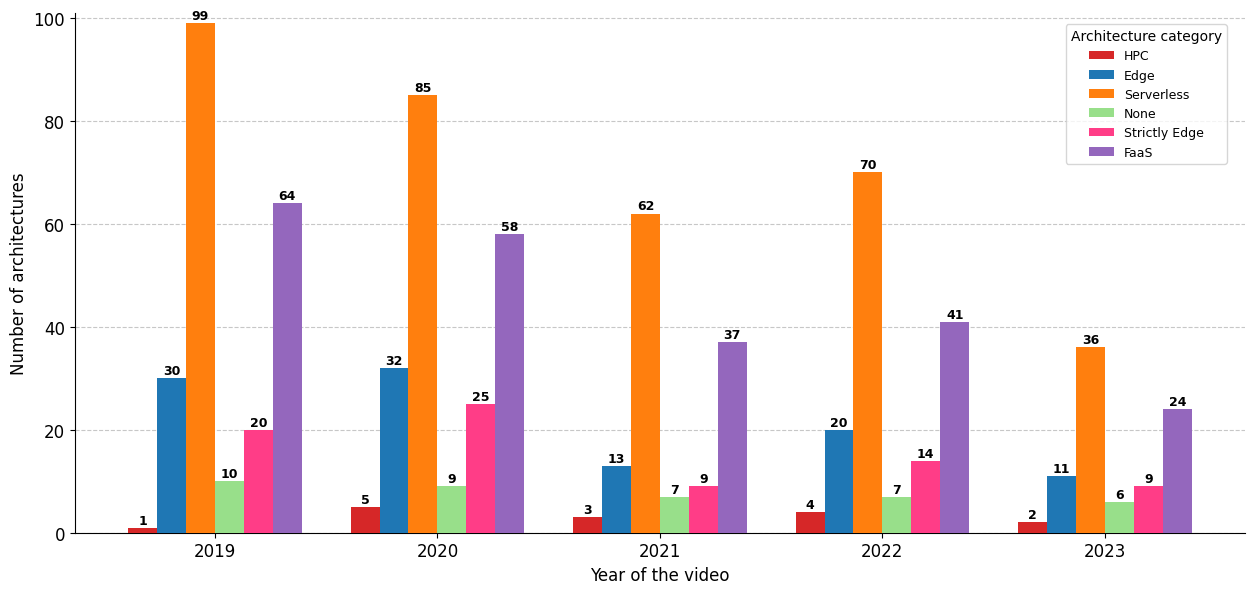

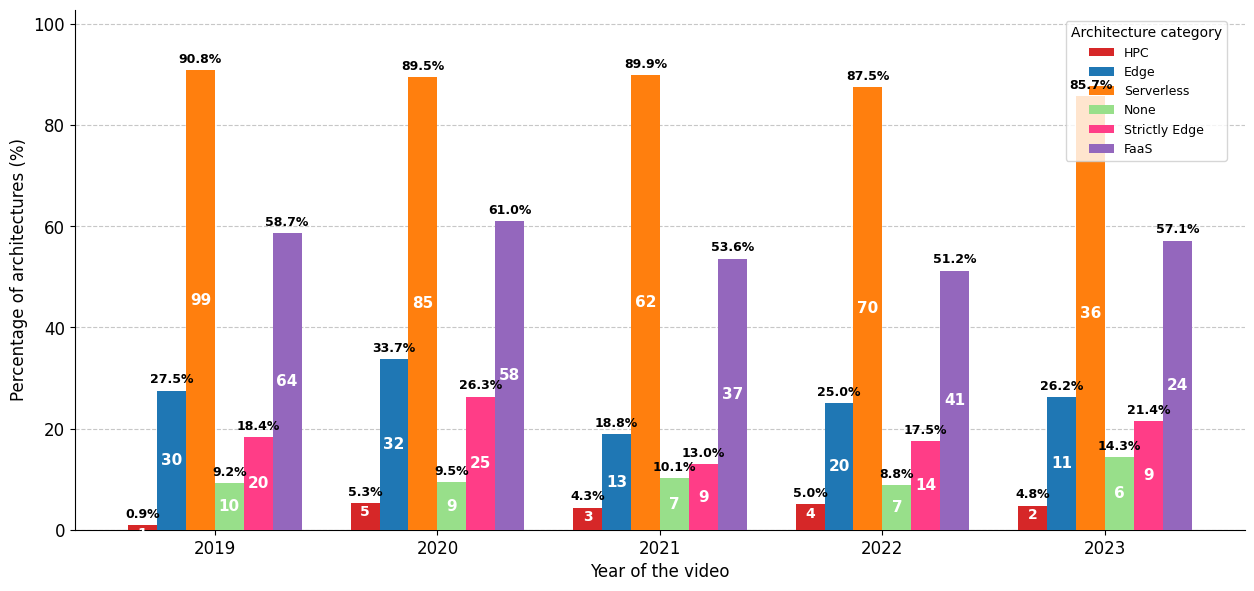

Files exported:
- Absolute counts EPS: /content/absolute_evolution_year_strictly_edge_faas.eps
- Percentage EPS: /content/percentage_evolution_year_strictly_edge_faas.eps
- Absolute counts CSV: /content/absolute_evolution_year_strictly_edge_faas.csv
- Percentage CSV: /content/percentage_evolution_year_strictly_edge_faas.csv
- Yearly totals CSV: /content/total_architectures_year.csv

Absolute yearly counts:


,HPC,Edge,Serverless,None,Strictly Edge,FaaS
2019,1,30,99,10,20,64
2020,5,32,85,9,25,58
2021,3,13,62,7,9,37
2022,4,20,70,7,14,41
2023,2,11,36,6,9,24



Yearly percentages:


,HPC,Edge,Serverless,None,Strictly Edge,FaaS
2019,0.92,27.52,90.83,9.17,18.35,58.72
2020,5.26,33.68,89.47,9.47,26.32,61.05
2021,4.35,18.84,89.86,10.14,13.04,53.62
2022,5.00,25.00,87.50,8.75,17.50,51.25
2023,4.76,26.19,85.71,14.29,21.43,57.14


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import ast
import re

# =========================================================
# Trend analysis by year:
# HPC, Edge, Serverless, None, Strictly Edge, and FaaS
# =========================================================

# --- Visual configuration ---
matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "savefig.format": "eps",
    "ps.fonttype": 42
})

# --- Colors by analytical category ---
ARCH_COLORS = {
    "HPC": "#D62728",
    "Edge": "#1F77B4",
    "Serverless": "#FF7F0E",
    "None": "#98DF8A",
    "Strictly Edge": "#ff3d87",
    "FaaS": "#9467BD"
}

# --- Required order in figures and CSV files ---
ordered_categories = [
    "HPC",
    "Edge",
    "Serverless",
    "None",
    "Strictly Edge",
    "FaaS"
]

# --- Category name -> dataframe boolean column ---
CATEGORY_FLAGS = {
    "HPC": "belongs_hpc",
    "Edge": "belongs_edge",
    "Serverless": "belongs_serverless",
    "None": "belongs_none_analytical",
    "Strictly Edge": "belongs_edge_no_cloudfront",
    "FaaS": "belongs_serverless_faas"
}


# =========================================================
# Helper functions
# =========================================================

def to_boolean(series):
    """Convert a column safely to boolean values."""
    if series.dtype == bool:
        return series.fillna(False)

    return (
        series
        .fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )


def parse_services(x):
    """Convert the services field into a clean Python list."""
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if pd.isna(x) or str(x).strip() == "":
        return []

    s = str(x).strip()

    try:
        value = ast.literal_eval(s)

        if isinstance(value, list):
            return [
                str(v).strip()
                for v in value
                if str(v).strip()
            ]
    except Exception:
        pass

    return [
        item.strip()
        for item in s.split(",")
        if item.strip()
    ]


def normalize_service_key(service):
    """
    Normalize service names for comparison.

    Examples:
    IoTCore, IoT Core, and iot-core become iotcore.
    """
    service = str(service).strip()
    service = re.sub(r"\s+", " ", service)

    return re.sub(
        r"[^A-Za-z0-9]+",
        "",
        service
    ).lower()


def save_eps(fig, output_path, extra_artists=()):
    """
    Save an EPS preserving labels, annotations, and legends
    located outside the main plotting area.
    """
    fig.canvas.draw()

    fig.savefig(
        output_path,
        format="eps",
        bbox_inches="tight",
        bbox_extra_artists=extra_artists,
        pad_inches=0.22
    )


# =========================================================
# Load dataset
# =========================================================

df = pd.read_csv("/content/architectures_with_year.csv").copy()

# Ensure missing types are treated as None.
df["tipo_arquitectura"] = df["tipo_arquitectura"].fillna("None")

# Ensure services_list is available to rebuild flags if needed.
df["services_list"] = df["services"].apply(parse_services)


# =========================================================
# Rebuild general analytical flags if needed
# =========================================================

if "belongs_edge" not in df.columns:
    df["belongs_edge"] = df["tipo_arquitectura"].isin(
        ["Edge", "Edge+HPC"]
    )

if "belongs_hpc" not in df.columns:
    df["belongs_hpc"] = df["tipo_arquitectura"].isin(
        ["HPC", "Edge+HPC"]
    )

if "belongs_serverless" not in df.columns:
    if "has_serverless" in df.columns:
        df["belongs_serverless"] = to_boolean(
            df["has_serverless"]
        )
    else:
        raise ValueError(
            "Columns 'belongs_serverless' and "
            "'has_serverless' were not found."
        )

if "belongs_none_analytical" not in df.columns:
    df["belongs_none_analytical"] = ~(
        df["belongs_edge"]
        | df["belongs_hpc"]
        | df["belongs_serverless"]
    )

# Ensure all general flags are booleans.
for column in [
    "belongs_edge",
    "belongs_hpc",
    "belongs_serverless",
    "belongs_none_analytical"
]:
    df[column] = to_boolean(df[column])


# =========================================================
# Rebuild Strictly Edge = Edge without CloudFront
# =========================================================

edge_services = [
    "Snowball", "Snowcone", "Snowmobile", "SnowFamily",
    "SageMakerNeo", "SageMakerEdgeManager", "Monitron",
    "Panorama", "RoboMaker",
    "CloudFront",
    "Greengrass", "FreeRTOS", "IoTCore", "IoTSiteWise",
    "AlexaForBusiness",
    "LocalZones", "Wavelength", "Outpost",
    "StorageGateway",
    "UserConsumerCamera", "UserCompanyEdge",
    "UserConsumerEdge", "UserConsumerIOT",
    "UserConsumerPOS", "UserCompanyDrone",
    "UserConsumerFarmer",
    "UserConsumerAlexaGoogleHome",
    "UserCompanyElementalLiveDevice",
    "UserConsumerTV",
    "LambdaAtEdge", "IoT1Click"
]

# CloudFront does not classify an architecture as Strictly Edge.
edge_services_no_cloudfront = [
    service
    for service in edge_services
    if normalize_service_key(service) != "cloudfront"
]

edge_no_cloudfront_keys = {
    normalize_service_key(service)
    for service in edge_services_no_cloudfront
}

if "belongs_edge_no_cloudfront" not in df.columns:

    df["services_normalized"] = df["services_list"].apply(
        lambda service_list: {
            normalize_service_key(service)
            for service in service_list
        }
    )

    df["belongs_edge_no_cloudfront"] = df[
        "services_normalized"
    ].apply(
        lambda normalized_services: len(
            normalized_services.intersection(
                edge_no_cloudfront_keys
            )
        ) > 0
    )

    print(
        "Column 'belongs_edge_no_cloudfront' was rebuilt "
        "using Edge discriminators excluding CloudFront."
    )

else:
    df["belongs_edge_no_cloudfront"] = to_boolean(
        df["belongs_edge_no_cloudfront"]
    )


# =========================================================
# Rebuild FaaS flag only if missing
# FaaS = Lambda or LambdaAtEdge
# =========================================================

serverless_faas = [
    "Lambda",
    "LambdaAtEdge"
]

faas_keys = {
    normalize_service_key(service)
    for service in serverless_faas
}

if "belongs_serverless_faas" not in df.columns:

    if "services_normalized" not in df.columns:
        df["services_normalized"] = df["services_list"].apply(
            lambda service_list: {
                normalize_service_key(service)
                for service in service_list
            }
        )

    df["belongs_serverless_faas"] = df[
        "services_normalized"
    ].apply(
        lambda normalized_services: len(
            normalized_services.intersection(faas_keys)
        ) > 0
    )

    print(
        "Column 'belongs_serverless_faas' was rebuilt "
        "using Lambda and LambdaAtEdge."
    )

else:
    df["belongs_serverless_faas"] = to_boolean(
        df["belongs_serverless_faas"]
    )


# =========================================================
# Filter records with valid year
# =========================================================

df["year_video"] = pd.to_numeric(
    df["year_video"],
    errors="coerce"
)

df_filtrado = df[
    df["year_video"].notnull()
].copy()

df_filtrado["year_video"] = df_filtrado[
    "year_video"
].astype(int)

years = sorted(df_filtrado["year_video"].unique())

if not years:
    raise ValueError(
        "No valid values were found in 'year_video'."
    )


# =========================================================
# Build yearly absolute counts
# =========================================================

conteo_anual = pd.DataFrame(
    index=years,
    columns=ordered_categories,
    data=0
)

for year in years:

    subset_year = df_filtrado[
        df_filtrado["year_video"] == year
    ].copy()

    for category in ordered_categories:

        flag_column = CATEGORY_FLAGS[category]

        conteo_anual.loc[year, category] = (
            subset_year.loc[
                subset_year[flag_column],
                "architecture"
            ]
            .nunique()
        )

conteo_anual = conteo_anual.astype(int)


# =========================================================
# Build yearly percentages
# Denominator: total unique architectures in each year
# =========================================================

total_year = (
    df_filtrado
    .groupby("year_video")["architecture"]
    .nunique()
    .reindex(years)
)

conteo_relativo = (
    conteo_anual
    .div(total_year, axis=0)
    * 100
).round(2)


# =========================================================
# Shared plotting parameters
# =========================================================

x = np.arange(len(years))
n_categories = len(ordered_categories)
bar_width = 0.13


# =========================================================
# 1. Absolute-count trend chart
# =========================================================

fig, ax1 = plt.subplots(figsize=(13, 6.5))

for i, category in enumerate(ordered_categories):

    offsets = x + (
        i - (n_categories - 1) / 2
    ) * bar_width

    values = conteo_anual[category].values

    bars = ax1.bar(
        offsets,
        values,
        width=bar_width,
        color=ARCH_COLORS[category],
        label=category,
        zorder=3
    )

    # Absolute values over each bar.
    for bar, value in zip(bars, values):
        if value > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.18,
                str(int(value)),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                clip_on=False,
                zorder=10
            )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.yaxis.grid(True, linestyle="--", alpha=0.7, zorder=0)
ax1.xaxis.grid(False)

ax1.set_ylabel("Number of architectures")
ax1.set_xlabel("Year of the video")
ax1.set_xticks(x)
ax1.set_xticklabels(years)

# Extra vertical space for values above the bars.
max_absolute = conteo_anual.to_numpy().max()
ax1.set_ylim(0, max(max_absolute + 2, 3))

legend1 = ax1.legend(
    title="Architecture category",
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    ncol=1,
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.94,
    bottom=0.14
)

absolute_eps_path = (
    "/content/absolute_evolution_year_"
    "strictly_edge_faas.eps"
)

save_eps(
    fig,
    absolute_eps_path,
    extra_artists=(legend1,)
)

plt.show()
plt.close(fig)


# =========================================================
# 2. Percentage trend chart
# =========================================================

fig, ax2 = plt.subplots(figsize=(13, 6.5))

for i, category in enumerate(ordered_categories):

    offsets = x + (
        i - (n_categories - 1) / 2
    ) * bar_width

    pct_values = conteo_relativo[category].values
    abs_values = conteo_anual[category].values

    bars = ax2.bar(
        offsets,
        pct_values,
        width=bar_width,
        color=ARCH_COLORS[category],
        label=category,
        zorder=3
    )

    for bar, percentage, absolute in zip(
        bars,
        pct_values,
        abs_values
    ):
        if percentage <= 0:
            continue

        x_center = bar.get_x() + bar.get_width() / 2
        height = bar.get_height()

        # Absolute value inside the bar.
        if height >= 8:
            ax2.text(
                x_center,
                height / 2,
                f"{int(absolute)}",
                ha="center",
                va="center",
                color="white",
                fontsize=11,
                fontweight="bold",
                clip_on=False,
                zorder=10
            )
        else:
            ax2.text(
                x_center,
                max(height - 0.4, 0.25),
                f"{int(absolute)}",
                ha="center",
                va="top",
                color="white",
                fontsize=10,
                fontweight="bold",
                clip_on=False,
                zorder=10
            )

        # Percentage above the bar.
        ax2.text(
            x_center,
            height + 0.9,
            f"{percentage:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="black",
            clip_on=False,
            zorder=10
        )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.yaxis.grid(True, linestyle="--", alpha=0.7, zorder=0)
ax2.xaxis.grid(False)

ax2.set_ylabel("Percentage of architectures (%)")
ax2.set_xlabel("Year of the video")
ax2.set_xticks(x)
ax2.set_xticklabels(years)

# Critical: leave enough vertical space for labels above bars.
max_percentage = conteo_relativo.to_numpy().max()
ax2.set_ylim(0, max(max_percentage + 12, 15))

legend2 = ax2.legend(
    title="Architecture category",
    loc="upper right",
    bbox_to_anchor=(0.99, 0.99),
    ncol=1,
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.94,
    bottom=0.14
)

percentage_eps_path = (
    "/content/percentage_evolution_year_"
    "strictly_edge_faas.eps"
)

save_eps(
    fig,
    percentage_eps_path,
    extra_artists=(legend2,)
)

plt.show()
plt.close(fig)


# =========================================================
# 3. Export CSV files
# =========================================================

absolute_csv_path = (
    "/content/absolute_evolution_year_"
    "strictly_edge_faas.csv"
)

percentage_csv_path = (
    "/content/percentage_evolution_year_"
    "strictly_edge_faas.csv"
)

totals_csv_path = (
    "/content/total_architectures_year.csv"
)

conteo_anual.to_csv(absolute_csv_path)
conteo_relativo.to_csv(percentage_csv_path)

total_year.rename(
    "Total_Architectures"
).to_csv(totals_csv_path)

print("Files exported:")
print(f"- Absolute counts EPS: {absolute_eps_path}")
print(f"- Percentage EPS: {percentage_eps_path}")
print(f"- Absolute counts CSV: {absolute_csv_path}")
print(f"- Percentage CSV: {percentage_csv_path}")
print(f"- Yearly totals CSV: {totals_csv_path}")

print("\nAbsolute yearly counts:")
display(conteo_anual)

print("\nYearly percentages:")
display(conteo_relativo)